In [ ]:
# 1️⃣ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Imports
import pandas as pd
import numpy as np
import os

# 3️⃣ Load saved train and validation sets
train_df = pd.read_csv('/content/drive/MyDrive/SkinLesionProject/train.csv')
val_df = pd.read_csv('/content/drive/MyDrive/SkinLesionProject/val.csv')

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Setup Done ✅")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
#done already
import os

project_path = "/content/drive/MyDrive/SkinLesionProject"
os.makedirs(project_path, exist_ok=True)

print("Project folder created successfully")

balanced_df.to_csv(f"{project_path}/balanced_dataset.csv", index=False)

train_df.to_csv(f"{project_path}/train.csv", index=False)
val_df.to_csv(f"{project_path}/val.csv", index=False)

Project folder created successfully


NameError: name 'balanced_df' is not defined

In [ ]:
!pip install kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip

Streaming output truncated to the last 5000 lines.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0029341.jpg  
  inflating: h

In [ ]:
!ls

HAM10000_images_part_1	hmnist_28_28_RGB.csv  sample_data
HAM10000_images_part_2	hmnist_8_8_L.csv      skin-cancer-mnist-ham10000.zip
HAM10000_metadata.csv	hmnist_8_8_RGB.csv
hmnist_28_28_L.csv	kaggle.json


In [ ]:
!rm -rf ham10000_images_part_1
!rm -rf ham10000_images_part_2

In [ ]:
import pandas as pd

#MetaData loading
df = pd.read_csv("HAM10000_metadata.csv")
df.head()

#Notes for understanding: Multiclass-classification, Input->Image, Output->one of 7 diseaseclasses


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
#number of classes
df['dx'].value_counts()    #this suggests me that the class is imbalance

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


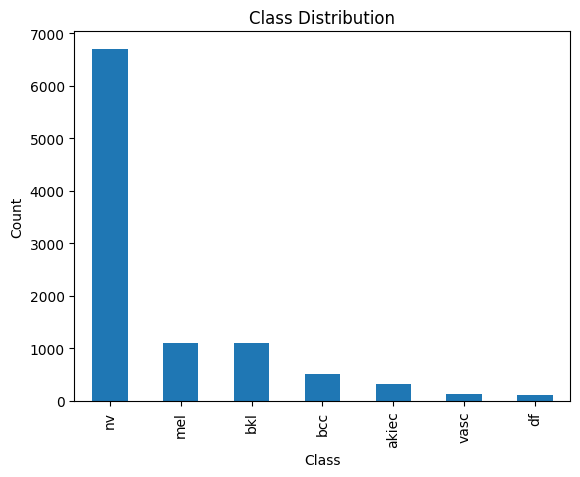

In [ ]:
#Analyzing class Imbalance graphically
import matplotlib.pyplot as plt

df['dx'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
#Preparing image paths
import os

image_dir1 = "HAM10000_images_part_1"
image_dir2 = "HAM10000_images_part_2"

def get_image_path(image_id):
    if os.path.exists(os.path.join(image_dir1, image_id + ".jpg")):
        return os.path.join(image_dir1, image_id + ".jpg")
    else:
        return os.path.join(image_dir2, image_id + ".jpg")

df['path'] = df['image_id'].apply(get_image_path)

df.head()  #that this image has this path linked to it

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,HAM10000_images_part_2/ISIC_0031633.jpg


 I do the undersampling for handling imbalance just for testing first later i will do class weights

In [ ]:
#creating balanced dataset
balanced_df = df.groupby('dx').apply(
    lambda x: x.sample(100, random_state=42)
).reset_index(drop=True)

balanced_df['dx'].value_counts()

/tmp/ipykernel_236/3099284589.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('dx').apply(


,count
dx,
akiec,100
bcc,100
bkl,100
df,100
mel,100
nv,100
vasc,100


In [ ]:
#train test split in 80/20 ratio using stratified sampling
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['dx']
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

#verifiying distribution (whether same class proportion)
print("Train distribution:\n", train_df['dx'].value_counts())
print("\nValidation distribution:\n", val_df['dx'].value_counts())

Training samples: 560
Validation samples: 140
Train distribution:
 dx
vasc     80
mel      80
bcc      80
bkl      80
nv       80
df       80
akiec    80
Name: count, dtype: int64

Validation distribution:
 dx
akiec    20
vasc     20
bcc      20
df       20
bkl      20
nv       20
mel      20
Name: count, dtype: int64


In [ ]:
#encoding label
# 1️⃣ Encode labels (convert dx → numbers)
# 2️⃣ Load images from path
# 3️⃣ Resize images
# 4️⃣ Normalize pixel values
# 5️⃣ Convert to NumPy arrays
# 6️⃣ Prepare data for CNN

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['dx'])
val_df['label'] = le.transform(val_df['dx'])
print(train_df[['dx','label']].head(10))

       dx  label
654  vasc      6
466   mel      4
637  vasc      6
176   bcc      1
220   bkl      2
564    nv      5
373    df      3
649  vasc      6
592    nv      5
151   bcc      1


In [ ]:
#Recreating images path for colab
import os

# Absolute paths inside Colab after unzip
image_dir1 = "/content/HAM10000_images_part_1"
image_dir2 = "/content/HAM10000_images_part_2"

def get_image_path(image_id):
    path1 = os.path.join(image_dir1, image_id + ".jpg")
    path2 = os.path.join(image_dir2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None  # safety check

# Recreate paths for train and validation sets
train_df['path'] = train_df['image_id'].apply(get_image_path)
val_df['path'] = val_df['image_id'].apply(get_image_path)

# Verify no missing images
print("Missing in train:", train_df['path'].isnull().sum())
print("Missing in val:", val_df['path'].isnull().sum())

Missing in train: 0
Missing in val: 0


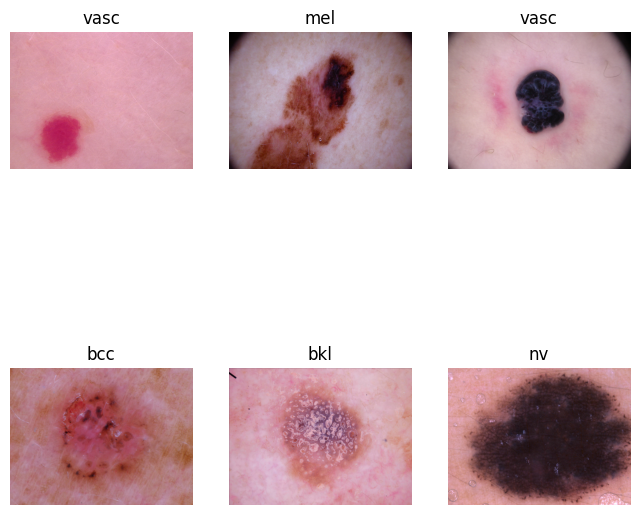

In [ ]:
#visualizing training dataset
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(8,8))

for i in range(6):
    img = cv2.imread(train_df['path'].iloc[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(train_df['dx'].iloc[i])
    plt.axis('off')

plt.show()

In [ ]:
!pip install torch torchvision --quiet

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

#Image transformations (augmentation and normalization)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_df.columns #to check whether label exists in train_df or not

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='object')

In [ ]:
#creating custom dataset to tell where images are stored and how labels are stored
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):  #Here is my data and how to process it
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)  #no of images

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

#datasets and dataloaders
train_dataset = SkinDataset(train_df, transform=train_transforms)
val_dataset = SkinDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #create batches for image
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

#pretrained ResNet50 model
model = torchvision.models.resnet50(pretrained=True)
num_classes = train_df['label'].nunique()
model.fc = nn.Linear(model.fc.in_features, num_classes) #total 7 classes for my case
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
#loss function
import torch.nn as nn
criterion = nn.CrossEntropyLoss()

#optimizer -> for updating model weights
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)  #model.paramaters include whole layers not just dense

#basic training loop
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 1.7936
Epoch [2/5], Loss: 1.4105
Epoch [3/5], Loss: 1.3007
Epoch [4/5], Loss: 1.2104
Epoch [5/5], Loss: 1.1057


In [ ]:
# Validation loop
model.eval()   # set model to evaluation mode
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():   # no gradient calculation
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss/len(val_loader):.4f}, "
      f"Validation Accuracy: {val_accuracy:.2f}%")

#slightly overfitting as training loss < validation loss

Validation Loss: 1.3232, Validation Accuracy: 50.00%


Class weights for handling imbalance practically

In [ ]:
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
y_encoded = le.fit_transform(df['dx'])
print("Class order:", list(le.classes_))  # check order

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
#print(df['dx'].value_counts())
print("Class weights:", class_weights)

Class order: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: tensor([ 4.3753,  2.7835,  1.3018, 12.4410,  1.2855,  0.2134, 10.0755])


In [ ]:
#image paths for whole dataset as i am doing class weights now
import os

# Absolute paths inside Colab after unzip
image_dir1 = "/content/HAM10000_images_part_1"
image_dir2 = "/content/HAM10000_images_part_2"

def get_image_path(image_id):
    path1 = os.path.join(image_dir1, image_id + ".jpg")
    path2 = os.path.join(image_dir2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None  # safety check

# Recreate paths for full dataset
df['image_path'] = df['image_id'].apply(get_image_path)

# Verify no missing images
print("Missing images in full dataset:", df['image_path'].isnull().sum())

Missing images in full dataset: 0


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encode labels
df['label']=y_encoded

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# -------------------------
#  Custom Dataset
# -------------------------
from PIL import Image
from torch.utils.data import Dataset

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# -------------------------
# 5️⃣ Train/Validation Split
# -------------------------
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -------------------------
# 6️⃣ Load Pretrained ResNet
# -------------------------
model = models.resnet18(pretrained=True)

# Freeze all layers except final fully connected
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))  # new classifier
model = model.to(device)

# -------------------------
# 7️⃣ Loss and Optimizer
# -------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # only train classifier

# -------------------------
# 8️⃣ Training Loop
# -------------------------
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# -------------------------
# 9️⃣ Evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)
val_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# -------------------------
#  🔟 Save Model
# -------------------------
torch.save(model.state_dict(), "resnet_ham10000_class_weights.pth")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5], Loss: 1.5796
Epoch [2/5], Loss: 1.2535
Epoch [3/5], Loss: 1.1710
Epoch [4/5], Loss: 1.1103
Epoch [5/5], Loss: 1.0662
Validation Accuracy: 69.25%
F1-score: 0.7122
Confusion Matrix:
 [[  41   18    1    0    3    2    0]
 [  19   63    5    1    3    8    4]
 [  43   22   89    4   23   30    9]
 [   4    5    0    7    2    5    0]
 [  40   22   20    0   82   54    5]
 [  31   53   50    4   86 1085   32]
 [   2    5    1    0    0    0   20]]


In [ ]:
#by unfreezing layers for more good results
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from PIL import Image
from torch.utils.data import Dataset
import numpy as np

# -------------------------
# 1️⃣ Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 2️⃣ Dataset & Labels
# -------------------------
# Assume df['label'] already contains encoded labels
# and class_weights tensor is already computed

# -------------------------
# 3️⃣ Transforms
# -------------------------
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# -------------------------
# 4️⃣ Custom Dataset
# -------------------------
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# -------------------------
# 5️⃣ Train/Validation Split
# -------------------------
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -------------------------
# 6️⃣ Load Pretrained ResNet18
# -------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# -------------------------
# 7️⃣ Fine-tuning: unfreeze last block
# -------------------------
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last convolutional block (layer4) + final dense layer
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(np.unique(df['label'])))
model = model.to(device)

# -------------------------
# 8️⃣ Loss and Optimizer
# -------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)  # small LR

# -------------------------
# 9️⃣ Training Loop (Fine-tuning)
# -------------------------
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# -------------------------
# 🔟 Evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)
val_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# -------------------------
# 1️⃣1️⃣ Save Fine-tuned Model
# -------------------------
torch.save(model.state_dict(), "resnet_ham10000_finetuned.pth")

KeyboardInterrupt: 

In [ ]:
model.eval()
train_correct = 0
train_total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

train_accuracy = 100 * train_correct / train_total
print(f"Training Accuracy: {train_accuracy:.2f}%")

Training Accuracy: 84.75%


In [ ]:
#now unfreeze more layers for more proper results
#by unfreezing layers for more good results
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from PIL import Image
from torch.utils.data import Dataset
import numpy as np

# -------------------------
# 1️⃣ Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 2️⃣ Dataset & Labels
# -------------------------
# Assume df['label'] already contains encoded labels
# and class_weights tensor is already computed

# -------------------------
# 3️⃣ Transforms
# -------------------------
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# -------------------------
# 4️⃣ Custom Dataset
# -------------------------
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# -------------------------
# 5️⃣ Train/Validation Split
# -------------------------
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -------------------------
# 6️⃣ Load Pretrained ResNet18
# -------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

# Unfreeze last convolutional blocks
for param in model.layer3.parameters(): #now unfreeze layer 3 also
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(np.unique(df['label'])))
model = model.to(device)

# -------------------------
# 8️⃣ Loss and Optimizer
# -------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)  # small LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2
)
# -------------------------
# 9️⃣ Training Loop (Fine-tuning)
# -------------------------
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)

    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
# -------------------------
# 🔟 Evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)
val_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# -------------------------
# 1️⃣1️⃣ Save Fine-tuned Model
# -------------------------
torch.save(model.state_dict(), "resnet_ham10000_finetuned.pth")

Epoch [1/10], Loss: 1.0499
Epoch [2/10], Loss: 0.6618
Epoch [3/10], Loss: 0.5447
Epoch [4/10], Loss: 0.4274
Epoch [5/10], Loss: 0.3725
Epoch [6/10], Loss: 0.3592
Epoch [7/10], Loss: 0.3101
Epoch [8/10], Loss: 0.2302
Epoch [9/10], Loss: 0.1787
Epoch [10/10], Loss: 0.2003
Validation Accuracy: 83.87%
F1-score: 0.8418
Confusion Matrix:
 [[  46    3    1    1   11    3    0]
 [   7   71    3    2   11    9    0]
 [  12    2  155    1   23   26    1]
 [   1    0    0   17    2    3    0]
 [   3    0   14    1  153   52    0]
 [   4    8   43    8   62 1215    1]
 [   0    1    1    0    2    1   23]]
